In [ ]:
import pretty_midi

midi = pretty_midi.PrettyMIDI("../data/clean_midi/The Cure/Friday I'm In Love.mid")

print(f"Duration: {midi.get_end_time():.2f} seconds")
print(f"Tempo: {midi.estimate_tempo():.1f} BPM")
print(f"Number of instruments: {len(midi.instruments)}")
print()

for i, inst in enumerate(midi.instruments):
    print(f"Instrument {i}: {inst.name or '(unnamed)'}, program={inst.program}, drums={inst.is_drum}, {len(inst.notes)} notes")

# Look at notes from the first non-drum instrument
melody = next((inst for inst in midi.instruments if not inst.is_drum), None)
if melody:
    print(f"\nFirst 15 notes from {melody.name or 'first melodic instrument'}:")
    for note in melody.notes[:15]:
        print(f"  pitch={note.pitch} ({pretty_midi.note_number_to_name(note.pitch)}), "
              f"start={note.start:.2f}s, end={note.end:.2f}s, velocity={note.velocity}")

Duration: 271.29 seconds
Tempo: 236.1 BPM
Number of instruments: 5

Instrument 0: Guitar-1, program=29, drums=False, 1056 notes
Instrument 1: Guitar-1, program=30, drums=False, 57 notes
Instrument 2: Guitar-2, program=30, drums=False, 511 notes
Instrument 3: Voice, program=91, drums=False, 439 notes
Instrument 4: Guitar-3, program=29, drums=False, 70 notes

First 15 notes from Guitar-1:
  pitch=74 (D5), start=0.45s, end=0.68s, velocity=110
  pitch=76 (E5), start=0.68s, end=0.90s, velocity=110
  pitch=78 (F#5), start=0.91s, end=1.13s, velocity=110
  pitch=76 (E5), start=1.14s, end=1.36s, velocity=110
  pitch=74 (D5), start=1.36s, end=1.59s, velocity=110
  pitch=76 (E5), start=1.59s, end=1.81s, velocity=110
  pitch=78 (F#5), start=1.82s, end=2.20s, velocity=110
  pitch=62 (D4), start=1.82s, end=2.20s, velocity=110
  pitch=69 (A4), start=1.82s, end=2.20s, velocity=110
  pitch=74 (D5), start=1.82s, end=2.20s, velocity=110
  pitch=74 (D5), start=2.27s, end=2.50s, velocity=110
  pitch=69 (A4

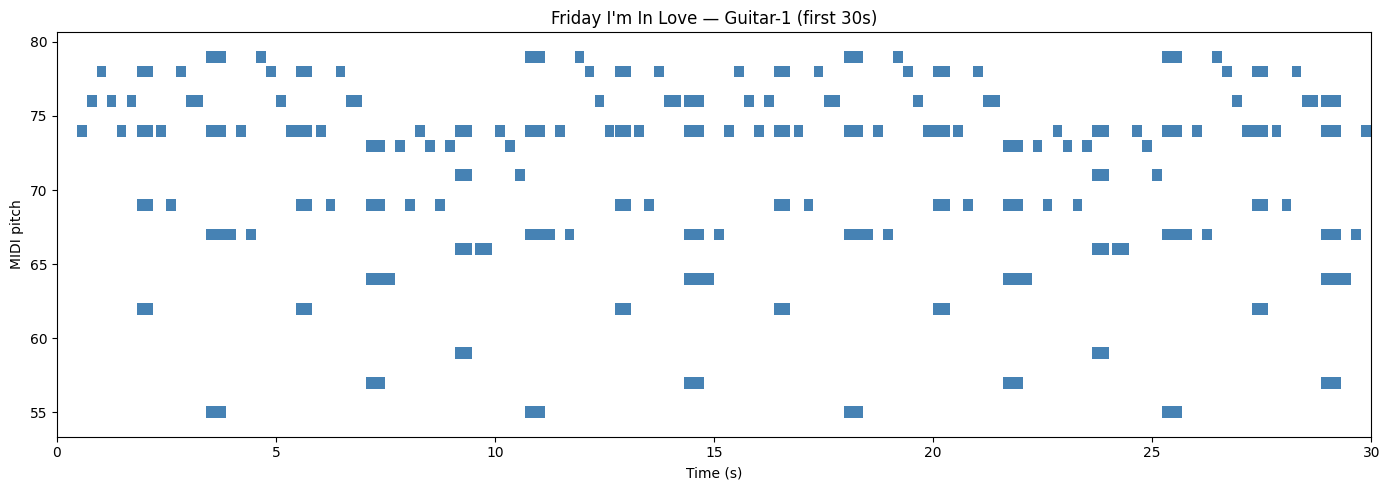

In [ ]:
## Visualizing the notes of the first non-drum instrument from Friday I'm In Love

import matplotlib.pyplot as plt
import numpy as np

# Pick a non-drum instrument with lots of notes
inst = midi.instruments[0]  # the main Guitar-1 with 1056 notes

# Plot first 30 seconds
fig, ax = plt.subplots(figsize=(14, 5))
for note in inst.notes:
    if note.start < 30:
        ax.barh(note.pitch, note.end - note.start, left=note.start, height=0.8, color='steelblue')

ax.set_xlabel('Time (s)')
ax.set_ylabel('MIDI pitch')
ax.set_title(f"Friday I'm In Love — {inst.name} (first 30s)")
ax.set_xlim(0, 30)
plt.tight_layout()
plt.show()

In [40]:
## Extracting the melody with the skyline algorithm

import pretty_midi

def extract_melody_skyline(midi, time_step=0.05):
    """
    Extract a monophonic melody from a MIDI file using the skyline algorithm.
    At each small time window, pick the highest-pitched note that's sounding.
    
    Args:
        midi: a PrettyMIDI object
        time_step: how often (in seconds) to sample. 0.05s = 50ms is fine for pop.
    
    Returns:
        A list of (time, pitch) tuples representing the melody.
    """
    # Gather all non-drum notes from all instruments
    all_notes = []
    for inst in midi.instruments:
        if not inst.is_drum:
            all_notes.extend(inst.notes)
    
    if not all_notes:
        return []
    
    # Sort by start time (helpful for any later analysis)
    all_notes.sort(key=lambda n: n.start)
    
    # Walk through time in steps, picking highest note at each step
    end_time = max(n.end for n in all_notes)
    melody = []
    last_pitch = None  # tracks the last pitch we recorded
    
    t = 0.0
    while t < end_time:
        # Find all notes that are currently sounding at time t
        sounding = [n for n in all_notes if n.start <= t < n.end]
        
        if sounding:
            # Pick the highest-pitched one
            highest = max(sounding, key=lambda n: n.pitch)
            # Only record if pitch changed (avoids duplicate entries while a note holds)
            if highest.pitch != last_pitch:
                melody.append((t, highest.pitch))
                last_pitch = highest.pitch
        else:
            # Silence — reset so the next note gets recorded even if same pitch
            last_pitch = None
        
        t += time_step
    
    return melody

In [41]:
midi = pretty_midi.PrettyMIDI("../data/clean_midi/The Cure/Friday I'm In Love.mid")
melody = extract_melody_skyline(midi)

print(f"Extracted {len(melody)} melody notes")
print("\nFirst 20 melody notes:")
for t, pitch in melody[:20]:
    print(f"  t={t:.2f}s, pitch={pitch} ({pretty_midi.note_number_to_name(pitch)})")

Extracted 669 melody notes

First 20 melody notes:
  t=0.50s, pitch=74 (D5)
  t=0.70s, pitch=76 (E5)
  t=0.95s, pitch=78 (F#5)
  t=1.15s, pitch=76 (E5)
  t=1.40s, pitch=74 (D5)
  t=1.60s, pitch=76 (E5)
  t=1.85s, pitch=78 (F#5)
  t=2.50s, pitch=76 (E5)
  t=2.75s, pitch=78 (F#5)
  t=3.00s, pitch=76 (E5)
  t=3.45s, pitch=79 (G5)
  t=3.90s, pitch=74 (D5)
  t=4.55s, pitch=79 (G5)
  t=4.80s, pitch=78 (F#5)
  t=5.00s, pitch=76 (E5)
  t=5.25s, pitch=74 (D5)
  t=5.50s, pitch=78 (F#5)
  t=6.15s, pitch=76 (E5)
  t=6.40s, pitch=78 (F#5)
  t=7.05s, pitch=81 (A5)


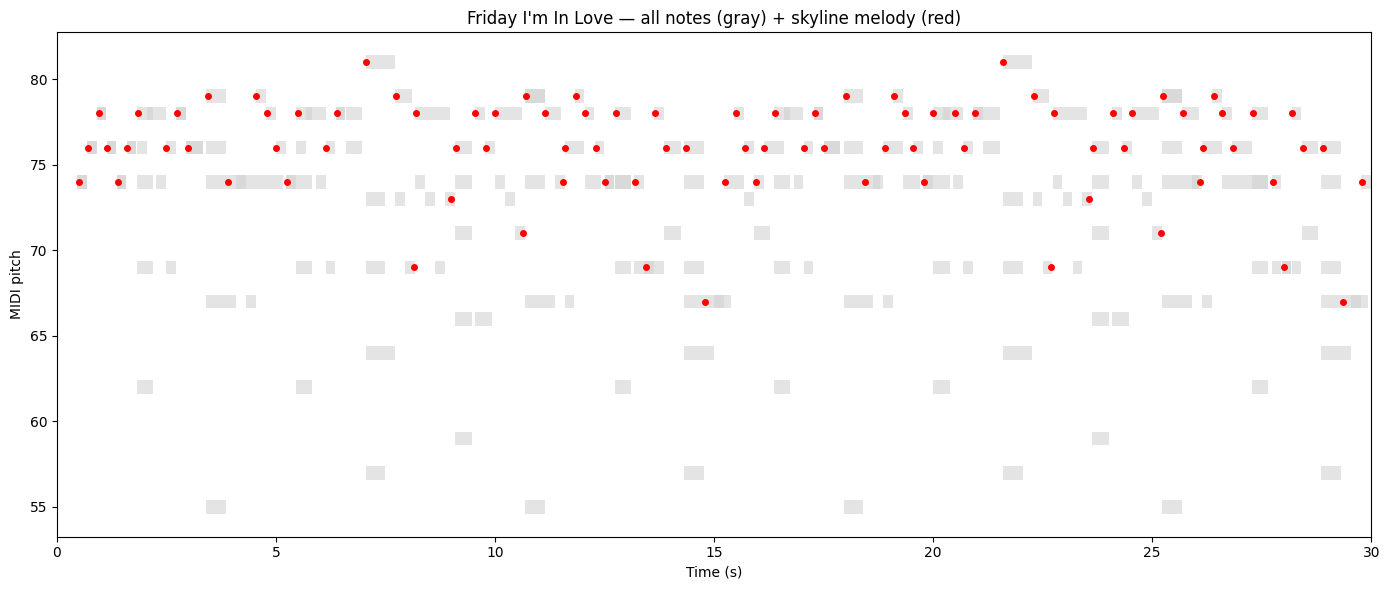

In [42]:
import matplotlib.pyplot as plt

# Plot first 30 seconds
fig, ax = plt.subplots(figsize=(14, 6))

# All non-drum notes in light gray
for inst in midi.instruments:
    if not inst.is_drum:
        for note in inst.notes:
            if note.start < 30:
                ax.barh(note.pitch, note.end - note.start, left=note.start, 
                        height=0.8, color='lightgray', alpha=0.6)

# Skyline melody in red
for t, pitch in melody:
    if t < 30:
        ax.plot(t, pitch, 'ro', markersize=4)

ax.set_xlabel('Time (s)')
ax.set_ylabel('MIDI pitch')
ax.set_title("Friday I'm In Love — all notes (gray) + skyline melody (red)")
ax.set_xlim(0, 30)
plt.tight_layout()
plt.show()

In [43]:
# Print first ~10 seconds of melody as note names
print("First 10 seconds of skyline melody:")
for t, pitch in melody:
    if t < 10:
        print(f"  t={t:.2f}s  {pretty_midi.note_number_to_name(pitch)}")

First 10 seconds of skyline melody:
  t=0.50s  D5
  t=0.70s  E5
  t=0.95s  F#5
  t=1.15s  E5
  t=1.40s  D5
  t=1.60s  E5
  t=1.85s  F#5
  t=2.50s  E5
  t=2.75s  F#5
  t=3.00s  E5
  t=3.45s  G5
  t=3.90s  D5
  t=4.55s  G5
  t=4.80s  F#5
  t=5.00s  E5
  t=5.25s  D5
  t=5.50s  F#5
  t=6.15s  E5
  t=6.40s  F#5
  t=7.05s  A5
  t=7.75s  G5
  t=8.15s  A4
  t=8.20s  F#5
  t=9.00s  C#5
  t=9.10s  E5
  t=9.55s  F#5
  t=9.80s  E5


In [44]:
import numpy as np
from IPython.display import Audio

def melody_to_audio(melody, sr=22050, note_duration=0.4):
    """Convert melody (list of (time, pitch)) into a simple sine-wave audio clip."""
    audio_segments = []
    for i, (t, pitch) in enumerate(melody):
        # Determine duration: until next note, or note_duration if last
        if i + 1 < len(melody):
            dur = melody[i + 1][0] - t
        else:
            dur = note_duration
        # Pitch to frequency: MIDI pitch n → 440 * 2^((n-69)/12)
        freq = 440 * 2 ** ((pitch - 69) / 12)
        # Generate sine wave at that frequency
        samples = int(sr * dur)
        wave = 0.3 * np.sin(2 * np.pi * freq * np.arange(samples) / sr)
        audio_segments.append(wave)
    return np.concatenate(audio_segments) if audio_segments else np.array([])

# Render first 15 seconds of melody
short_melody = [(t, p) for t, p in melody if t < 15]
audio = melody_to_audio(short_melody)

# Play it in the notebook
Audio(audio, rate=22050)

In [45]:
def melody_to_intervals(melody):
    """Convert melody [(t, pitch), ...] to a list of pitch intervals (in semitones)."""
    if len(melody) < 2:
        return []
    intervals = []
    for i in range(1, len(melody)):
        prev_pitch = melody[i-1][1]
        curr_pitch = melody[i][1]
        intervals.append(curr_pitch - prev_pitch)
    return intervals

intervals = melody_to_intervals(melody)
print(f"Total intervals: {len(intervals)}")
print(f"First 30 intervals: {intervals[:30]}")

Total intervals: 668
First 30 intervals: [2, 2, -2, -2, 2, 2, -2, 2, -2, 3, -5, 5, -1, -2, -2, 4, -2, 2, 3, -2, -10, 9, -5, 3, 2, -2, 2, -7, 8, -1]
